In [3]:
import torch
import torch.optim as optim
import torch.nn as nn

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda:0


In [5]:
from torchvision import transforms
from data.dataset import CustomImageDataset

train_transforms = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.RandomGrayscale(p=0.1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CustomImageDataset(root_dir='../dataset/train', transform=train_transforms)
test_dataset  = CustomImageDataset(root_dir='../dataset/test', transform=test_transforms)

In [6]:
from torch.utils.data import WeightedRandomSampler

class_counts = train_dataset.get_class_counts()

weights_per_class = {
    0: 1.0 / class_counts[0],
    1: 1.0 / class_counts[1]
}

sample_weights = [weights_per_class[label] for label in train_dataset.labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [7]:
from classifier.model import ImageArtifactClassifierCNN, ImageArtifactClassifierSimpleCNN, ResNet18ArtifactClassifier, EfficientNetArtifactClassifier
from scripts.helpers import random_search

In [8]:
param_space_cnn = {
    'lr': [1e-3, 5e-4, 1e-4],
    'batch_size': [16, 32, 64],
    'weight_decay': [0.0, 1e-4, 1e-5]
}

print("=== Custom Simple CNN Tuning (Random Search) ===")
best_cnn_simple_params = random_search(
    lambda: ImageArtifactClassifierSimpleCNN(num_classes=2),
    train_dataset,
    test_dataset,
    param_space_cnn,
    sampler,
    num_trials=6, 
    device=device
)

=== Custom Simple CNN Tuning (Random Search) ===
Starting Random Search. Total trials: 6

--- Experiment 1/6 | LR: 0.001, Batch Size: 16, Weight Decay: 0.0001 ---
Result of combination 1: Micro F1 = 0.5300

--- Experiment 2/6 | LR: 0.001, Batch Size: 32, Weight Decay: 1e-05 ---
Result of combination 2: Micro F1 = 0.6750

--- Experiment 3/6 | LR: 0.0005, Batch Size: 16, Weight Decay: 1e-05 ---
Result of combination 3: Micro F1 = 0.8400

--- Experiment 4/6 | LR: 0.0005, Batch Size: 16, Weight Decay: 0.0 ---
Result of combination 4: Micro F1 = 0.7300

--- Experiment 5/6 | LR: 0.0005, Batch Size: 64, Weight Decay: 1e-05 ---
Result of combination 5: Micro F1 = 0.7250

--- Experiment 6/6 | LR: 0.0005, Batch Size: 64, Weight Decay: 0.0001 ---
Result of combination 6: Micro F1 = 0.7850

🏆 (peremoga) Best parameters: {'lr': 0.0005, 'batch_size': 16, 'weight_decay': 1e-05} (F1: 0.8400)


In [9]:
print("=== Custom Better CNN Tuning (Random Search) ===")
best_cnn_better_params = random_search(
    lambda: ImageArtifactClassifierCNN(num_classes=2),
    train_dataset,
    test_dataset,
    param_space_cnn,
    sampler,
    num_trials=6, 
    device=device
)

=== Custom Better CNN Tuning (Random Search) ===
Starting Random Search. Total trials: 6

--- Experiment 1/6 | LR: 0.0005, Batch Size: 64, Weight Decay: 0.0 ---
Result of combination 1: Micro F1 = 0.5050

--- Experiment 2/6 | LR: 0.001, Batch Size: 32, Weight Decay: 1e-05 ---
Result of combination 2: Micro F1 = 0.7050

--- Experiment 3/6 | LR: 0.0005, Batch Size: 16, Weight Decay: 1e-05 ---
Result of combination 3: Micro F1 = 0.6600

--- Experiment 4/6 | LR: 0.001, Batch Size: 32, Weight Decay: 0.0001 ---
Result of combination 4: Micro F1 = 0.7800

--- Experiment 5/6 | LR: 0.0005, Batch Size: 16, Weight Decay: 0.0001 ---
Result of combination 5: Micro F1 = 0.4850

--- Experiment 6/6 | LR: 0.001, Batch Size: 32, Weight Decay: 1e-05 ---
Result of combination 6: Micro F1 = 0.6950

🏆 (peremoga) Best parameters: {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001} (F1: 0.7800)


In [10]:
param_space_resnet = {
    'lr': [1e-4, 5e-5, 1e-5],
    'batch_size': [16, 32],
    'weight_decay': [0.0, 1e-5]
}

print("\n=== ResNet-18 Tuning (Random Search) ===")
best_resnet_params = random_search(
    lambda: ResNet18ArtifactClassifier(num_classes=2, pretrained=True),
    train_dataset,
    test_dataset,
    param_space_resnet,
    sampler,
    num_trials=4,
    device=device
)


=== ResNet-18 Tuning (Random Search) ===
Starting Random Search. Total trials: 4

--- Experiment 1/4 | LR: 0.0001, Batch Size: 16, Weight Decay: 0.0 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Marina/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Result of combination 1: Micro F1 = 0.9600

--- Experiment 2/4 | LR: 0.0001, Batch Size: 16, Weight Decay: 1e-05 ---
Result of combination 2: Micro F1 = 0.9150

--- Experiment 3/4 | LR: 0.0001, Batch Size: 32, Weight Decay: 0.0 ---
Result of combination 3: Micro F1 = 0.9350

--- Experiment 4/4 | LR: 5e-05, Batch Size: 16, Weight Decay: 1e-05 ---
Result of combination 4: Micro F1 = 0.9100

🏆 (peremoga) Best parameters: {'lr': 0.0001, 'batch_size': 16, 'weight_decay': 0.0} (F1: 0.9600)


In [11]:
param_space_efficient = {
    'lr': [1e-4, 5e-5, 1e-5], 
    'batch_size': [16, 32], 
    'weight_decay': [1e-4, 1e-5] 
}

print("\n=== EfficientNet-B0 Tuning ===")
best_eff_params = random_search(
    lambda: EfficientNetArtifactClassifier(num_classes=2, pretrained=True),
    train_dataset,
    test_dataset,
    param_space_efficient,
    sampler,
    num_trials=4,
    device=device
)


=== EfficientNet-B0 Tuning ===
Starting Random Search. Total trials: 4

--- Experiment 1/4 | LR: 5e-05, Batch Size: 32, Weight Decay: 1e-05 ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Marina/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Result of combination 1: Micro F1 = 0.8400

--- Experiment 2/4 | LR: 0.0001, Batch Size: 16, Weight Decay: 1e-05 ---
Result of combination 2: Micro F1 = 0.9500

--- Experiment 3/4 | LR: 1e-05, Batch Size: 32, Weight Decay: 1e-05 ---
Result of combination 3: Micro F1 = 0.6450

--- Experiment 4/4 | LR: 0.0001, Batch Size: 16, Weight Decay: 1e-05 ---
Result of combination 4: Micro F1 = 0.9250

🏆 (peremoga) Best parameters: {'lr': 0.0001, 'batch_size': 16, 'weight_decay': 1e-05} (F1: 0.9500)


In [12]:
from torch.utils.data import DataLoader

train_loader_simple_cnn = DataLoader(
    train_dataset,
    batch_size=best_cnn_simple_params['batch_size'],
    sampler=sampler,
    num_workers=4
)

train_loader_better_cnn = DataLoader(
    train_dataset,
    batch_size=best_cnn_better_params['batch_size'],
    sampler=sampler,
    num_workers=4
)

train_loader_resnet = DataLoader(
    train_dataset,
    batch_size=best_resnet_params['batch_size'],
    sampler=sampler,
    num_workers=4
)

train_loader_efficientnet = DataLoader(
    train_dataset,
    batch_size=best_eff_params['batch_size'],
    sampler=sampler,
    num_workers=4
)

test_loader  = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2)

Examples of Augmented Images (Train Set):
image batch dim: torch.Size([16, 3, 224, 224])
label batch dim: torch.Size([16])
final layer dim: torch.Size([2])
class 0 count: 10
class 1 count: 6


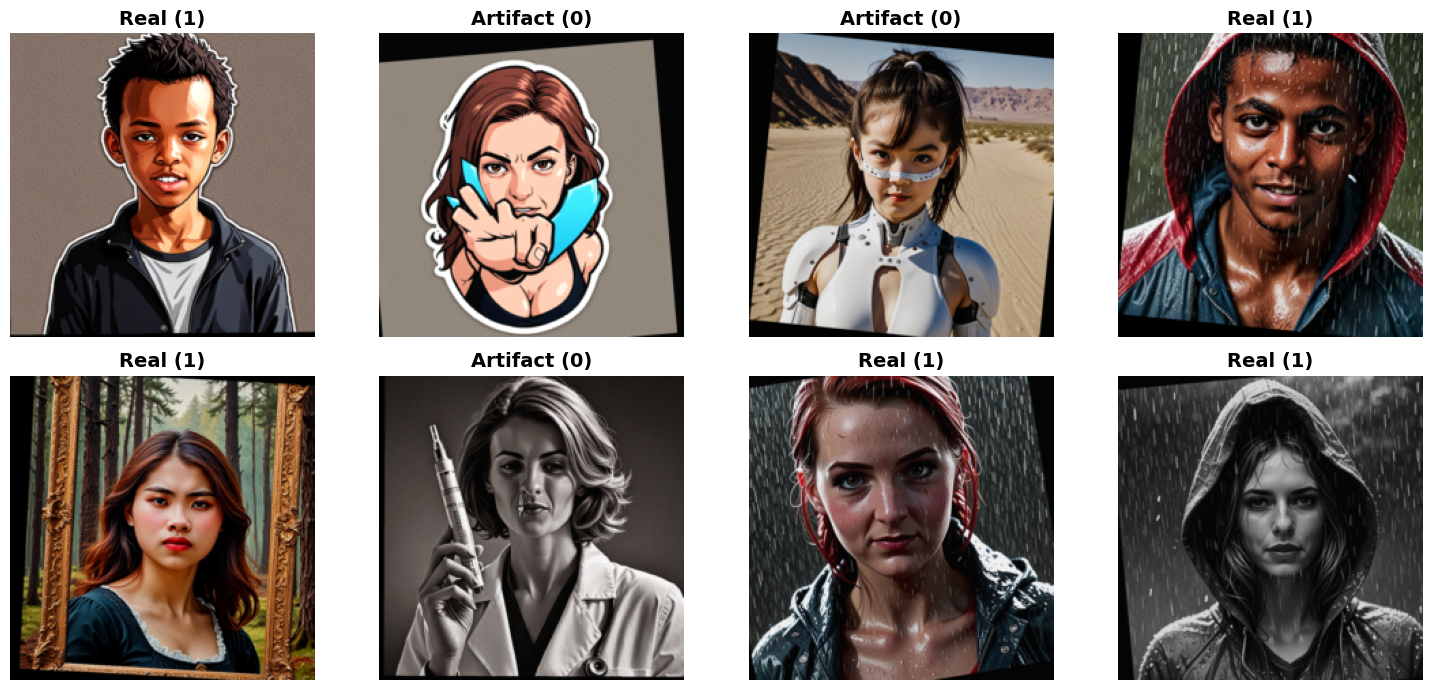

In [13]:
from scripts.helpers import show_augmented_images

print("Examples of Augmented Images (Train Set):")

dataiter = iter(train_loader_simple_cnn)
images, labels = next(dataiter)

print(f"image batch dim: {images.shape}")
print(f"label batch dim: {labels.shape}")
print(f"final layer dim: {labels.unique().shape}")
print(f"class 0 count: {labels[labels == 0].shape[0]}")
print(f"class 1 count: {labels[labels == 1].shape[0]}")

show_augmented_images(train_loader_simple_cnn, num_images=8)

In [14]:
simple_cnn_model = ImageArtifactClassifierSimpleCNN(num_classes=2).to(device)

better_cnn_model = ImageArtifactClassifierCNN(num_classes=2).to(device)

resnet_model = ResNet18ArtifactClassifier(num_classes=2, pretrained=True).to(device)

efficientnet_model = EfficientNetArtifactClassifier(num_classes=2, pretrained=True).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_simple_cnn = optim.Adam(
    simple_cnn_model.parameters(),
    lr=best_cnn_simple_params['lr'],
    weight_decay=best_cnn_simple_params['weight_decay'])

optimizer_better_cnn = optim.Adam(
    better_cnn_model.parameters(),
    lr=best_cnn_better_params['lr'],
    weight_decay=best_cnn_better_params['weight_decay'])

optimizer_efficientnet = optim.Adam(
    efficientnet_model.parameters(),
    lr=best_eff_params['lr'],
    weight_decay=best_eff_params['weight_decay'])

optimizer_resnet = optim.Adam(
    resnet_model.parameters(),
    lr=best_resnet_params['lr'],
    weight_decay=best_resnet_params['weight_decay'])

In [15]:
from scripts.helpers import train_model_with_metrics

trained_model_simple_cnn, training_history_simple_cnn = train_model_with_metrics(
    simple_cnn_model,
    train_loader_simple_cnn,
    test_loader,
    criterion,
    optimizer_simple_cnn,
    num_epochs=15,
    device=device)


Epoch 1/15
----------
Train Loss: 1.1905 Micro F1: 0.6261
Val Loss: 0.5965 Micro F1: 0.6700

Epoch 2/15
----------
Train Loss: 0.5982 Micro F1: 0.7028
Val Loss: 0.5455 Micro F1: 0.7250

Epoch 3/15
----------
Train Loss: 0.5475 Micro F1: 0.7322
Val Loss: 0.6940 Micro F1: 0.6500

Epoch 4/15
----------
Train Loss: 0.5502 Micro F1: 0.7278
Val Loss: 0.5881 Micro F1: 0.7450

Epoch 5/15
----------
Train Loss: 0.5384 Micro F1: 0.7333
Val Loss: 0.4574 Micro F1: 0.7550

Epoch 6/15
----------
Train Loss: 0.5514 Micro F1: 0.7400
Val Loss: 0.3887 Micro F1: 0.7900

Epoch 7/15
----------
Train Loss: 0.5335 Micro F1: 0.7422
Val Loss: 0.3777 Micro F1: 0.8450

Epoch 8/15
----------
Train Loss: 0.4992 Micro F1: 0.7583
Val Loss: 0.4093 Micro F1: 0.8050

Epoch 9/15
----------
Train Loss: 0.5084 Micro F1: 0.7594
Val Loss: 0.3900 Micro F1: 0.8000

Epoch 10/15
----------
Train Loss: 0.4959 Micro F1: 0.7672
Val Loss: 0.4606 Micro F1: 0.7900

Epoch 11/15
----------
Train Loss: 0.4880 Micro F1: 0.7717
Val Loss:

In [17]:
trained_model_better_cnn, training_history_better_cnn = train_model_with_metrics(
    better_cnn_model,
    train_loader_better_cnn,
    test_loader,
    criterion,
    optimizer_better_cnn,
    num_epochs=15,
    device=device)


Epoch 1/15
----------
Train Loss: 0.6308 Micro F1: 0.6733
Val Loss: 0.3515 Micro F1: 0.8550

Epoch 2/15
----------
Train Loss: 0.6155 Micro F1: 0.6883
Val Loss: 0.8098 Micro F1: 0.6350

Epoch 3/15
----------
Train Loss: 0.6145 Micro F1: 0.6811
Val Loss: 0.4359 Micro F1: 0.8050

Epoch 4/15
----------
Train Loss: 0.5973 Micro F1: 0.6933
Val Loss: 0.6346 Micro F1: 0.6550

Epoch 5/15
----------
Train Loss: 0.6036 Micro F1: 0.7011
Val Loss: 0.4434 Micro F1: 0.7200

Epoch 6/15
----------
Train Loss: 0.6106 Micro F1: 0.6850
Val Loss: 0.5726 Micro F1: 0.7050

Epoch 7/15
----------
Train Loss: 0.5842 Micro F1: 0.7189
Val Loss: 0.4986 Micro F1: 0.8100

Epoch 8/15
----------
Train Loss: 0.6011 Micro F1: 0.6939
Val Loss: 0.7397 Micro F1: 0.5900

Epoch 9/15
----------
Train Loss: 0.5988 Micro F1: 0.6994
Val Loss: 0.5523 Micro F1: 0.7150

Epoch 10/15
----------
Train Loss: 0.5940 Micro F1: 0.7000
Val Loss: 0.5896 Micro F1: 0.7150

Epoch 11/15
----------
Train Loss: 0.5770 Micro F1: 0.7144
Val Loss:

In [18]:
trained_model_resnet, training_history_resnet = train_model_with_metrics(
    resnet_model,
    train_loader_resnet,
    test_loader,
    criterion,
    optimizer_resnet,
    num_epochs=15,
    device=device)


Epoch 1/15
----------
Train Loss: 0.4267 Micro F1: 0.8094
Val Loss: 0.3322 Micro F1: 0.8700

Epoch 2/15
----------
Train Loss: 0.2083 Micro F1: 0.9222
Val Loss: 0.1940 Micro F1: 0.9550

Epoch 3/15
----------
Train Loss: 0.1386 Micro F1: 0.9517
Val Loss: 0.2137 Micro F1: 0.9500

Epoch 4/15
----------
Train Loss: 0.1135 Micro F1: 0.9606
Val Loss: 0.1780 Micro F1: 0.9500

Epoch 5/15
----------
Train Loss: 0.0926 Micro F1: 0.9633
Val Loss: 0.1763 Micro F1: 0.9600

Epoch 6/15
----------
Train Loss: 0.0541 Micro F1: 0.9789
Val Loss: 0.1940 Micro F1: 0.9550

Epoch 7/15
----------
Train Loss: 0.0639 Micro F1: 0.9761
Val Loss: 0.1992 Micro F1: 0.9500

Epoch 8/15
----------
Train Loss: 0.0633 Micro F1: 0.9744
Val Loss: 0.2220 Micro F1: 0.9450

Epoch 9/15
----------
Train Loss: 0.0326 Micro F1: 0.9906
Val Loss: 0.2462 Micro F1: 0.9500

Epoch 10/15
----------
Train Loss: 0.0273 Micro F1: 0.9900
Val Loss: 0.1888 Micro F1: 0.9500

Epoch 11/15
----------
Train Loss: 0.0377 Micro F1: 0.9856
Val Loss:

In [19]:
trained_model_efficientnet, training_history_efficientnet = train_model_with_metrics(
    efficientnet_model,
    train_loader_efficientnet,
    test_loader,
    criterion,
    optimizer_efficientnet,
    num_epochs=15,
    device=device)


Epoch 1/15
----------
Train Loss: 0.5149 Micro F1: 0.7433
Val Loss: 0.3888 Micro F1: 0.8400

Epoch 2/15
----------
Train Loss: 0.3019 Micro F1: 0.8828
Val Loss: 0.2681 Micro F1: 0.8850

Epoch 3/15
----------
Train Loss: 0.1895 Micro F1: 0.9294
Val Loss: 0.2277 Micro F1: 0.9250

Epoch 4/15
----------
Train Loss: 0.1303 Micro F1: 0.9528
Val Loss: 0.2529 Micro F1: 0.9050

Epoch 5/15
----------
Train Loss: 0.0838 Micro F1: 0.9711
Val Loss: 0.3858 Micro F1: 0.8750

Epoch 6/15
----------
Train Loss: 0.0730 Micro F1: 0.9717
Val Loss: 0.2984 Micro F1: 0.9350

Epoch 7/15
----------
Train Loss: 0.0590 Micro F1: 0.9789
Val Loss: 0.2571 Micro F1: 0.9450

Epoch 8/15
----------
Train Loss: 0.0622 Micro F1: 0.9767
Val Loss: 0.3088 Micro F1: 0.9400

Epoch 9/15
----------
Train Loss: 0.0407 Micro F1: 0.9839
Val Loss: 0.2697 Micro F1: 0.9500

Epoch 10/15
----------
Train Loss: 0.0470 Micro F1: 0.9833
Val Loss: 0.2921 Micro F1: 0.9500

Epoch 11/15
----------
Train Loss: 0.0368 Micro F1: 0.9867
Val Loss:

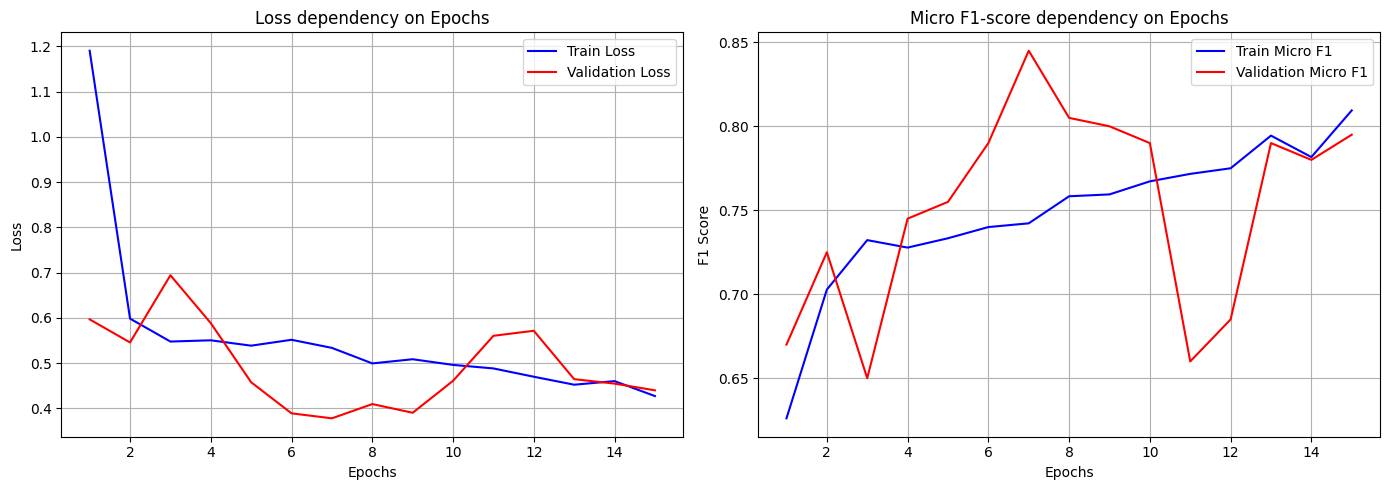

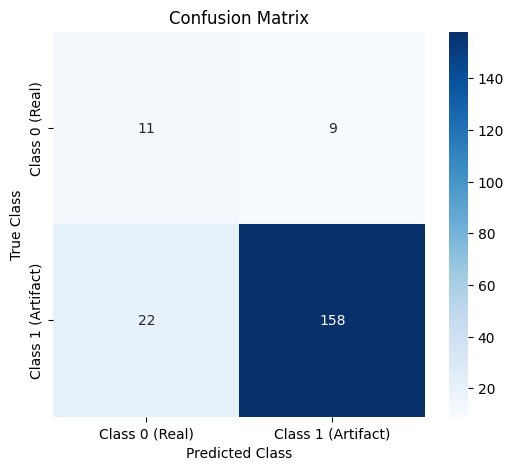


--- DETAILED ANALYSIS ---
Total images checked: 200
True Negatives (TN): 11 - Real photos that the model correctly identified as real.
False Positives (FP): 9 - WARNING! Real photos that the model incorrectly identified as artifacts (fakes).
False Negatives (FN): 22 - Generated photos (artifacts), which the model missed.
True Positives (TP): 158 - Generated photos that the model successfully detected.

Specificity (Ability to not block real photos): 0.5500


In [23]:
from scripts.helpers import plot_training_history, evaluate_confusion_matrix

plot_training_history(training_history_simple_cnn) # Simple CNN Training History
evaluate_confusion_matrix(trained_model_simple_cnn, test_loader, device=device)

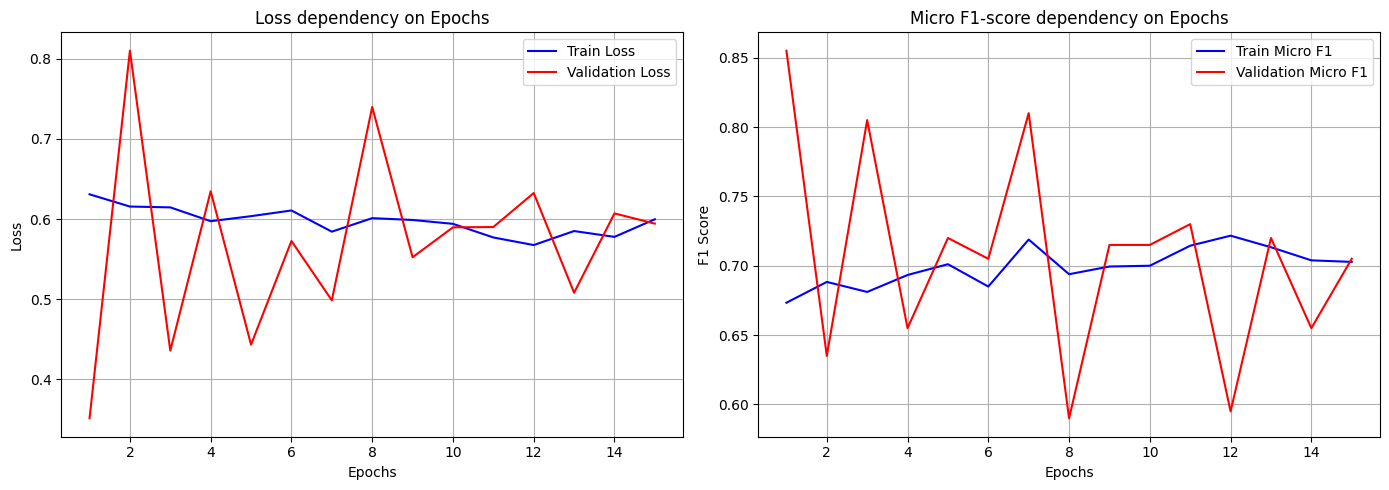

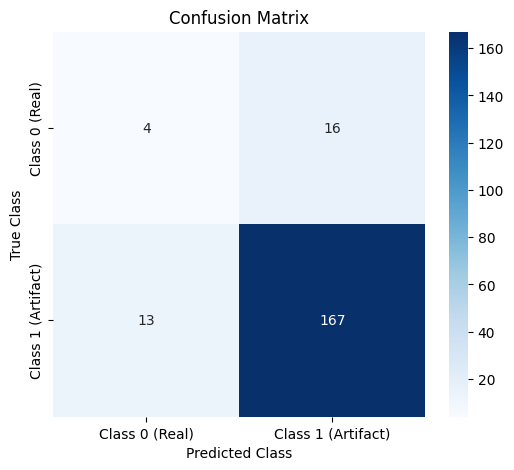


--- DETAILED ANALYSIS ---
Total images checked: 200
True Negatives (TN): 4 - Real photos that the model correctly identified as real.
False Positives (FP): 16 - WARNING! Real photos that the model incorrectly identified as artifacts (fakes).
False Negatives (FN): 13 - Generated photos (artifacts), which the model missed.
True Positives (TP): 167 - Generated photos that the model successfully detected.

Specificity (Ability to not block real photos): 0.2000


In [24]:
plot_training_history(training_history_better_cnn) # Better CNN Training History
evaluate_confusion_matrix(trained_model_better_cnn, test_loader, device=device)

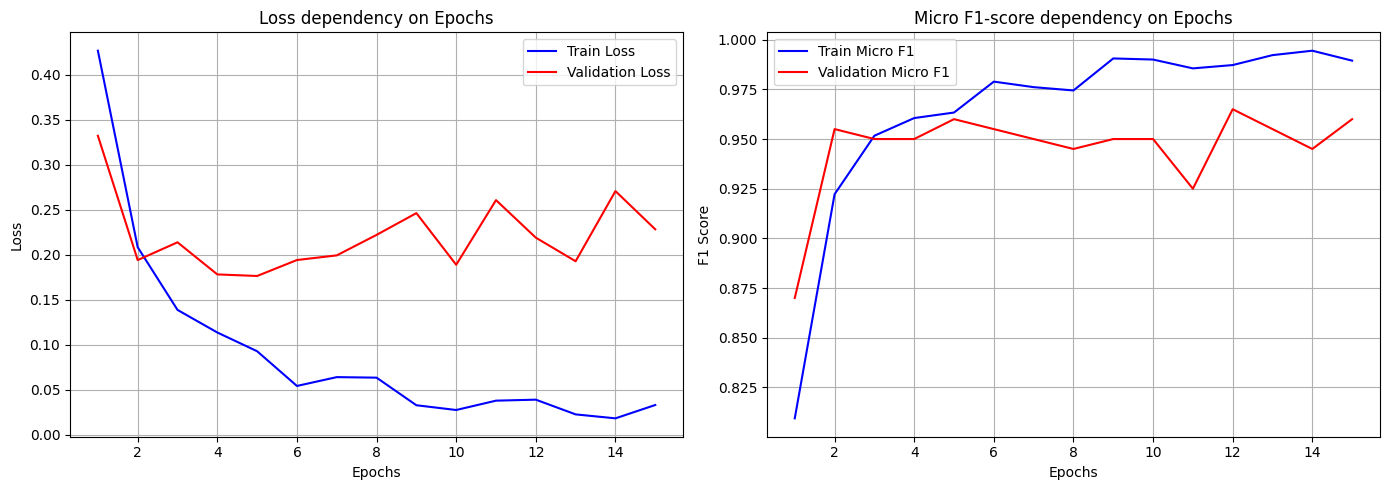

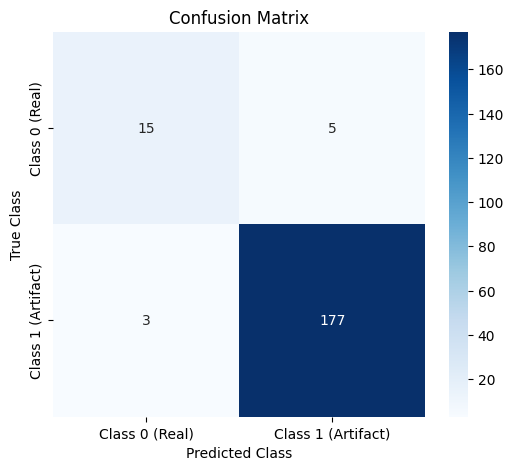


--- DETAILED ANALYSIS ---
Total images checked: 200
True Negatives (TN): 15 - Real photos that the model correctly identified as real.
False Positives (FP): 5 - WARNING! Real photos that the model incorrectly identified as artifacts (fakes).
False Negatives (FN): 3 - Generated photos (artifacts), which the model missed.
True Positives (TP): 177 - Generated photos that the model successfully detected.

Specificity (Ability to not block real photos): 0.7500


In [25]:
plot_training_history(training_history_resnet)
evaluate_confusion_matrix(trained_model_resnet, test_loader, device=device)

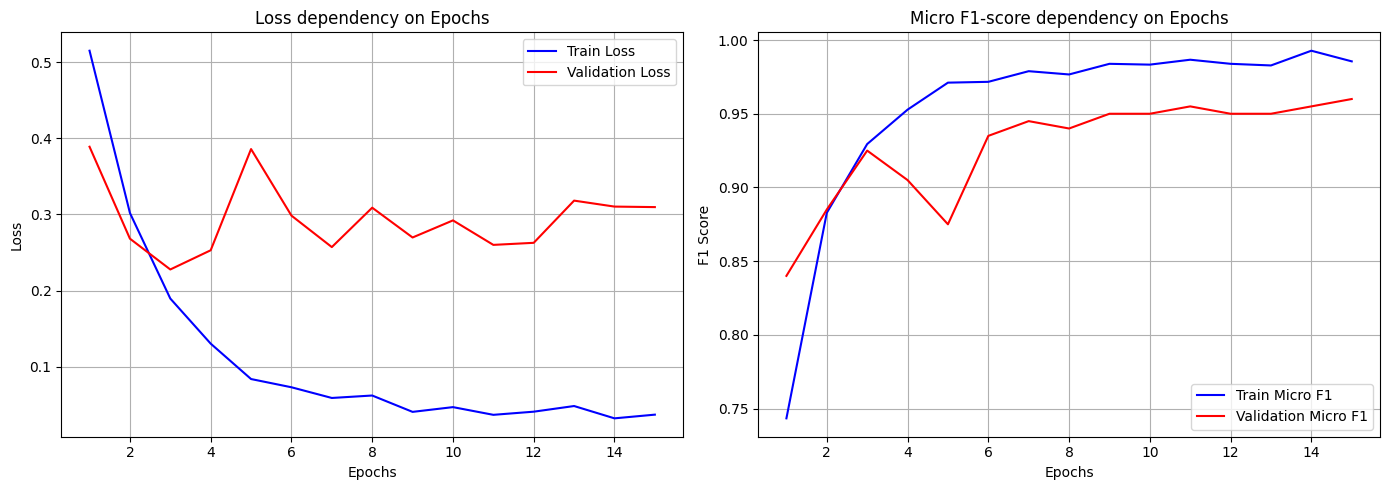

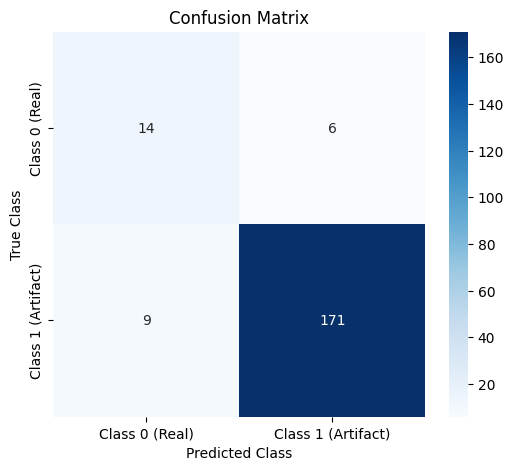


--- DETAILED ANALYSIS ---
Total images checked: 200
True Negatives (TN): 14 - Real photos that the model correctly identified as real.
False Positives (FP): 6 - WARNING! Real photos that the model incorrectly identified as artifacts (fakes).
False Negatives (FN): 9 - Generated photos (artifacts), which the model missed.
True Positives (TP): 171 - Generated photos that the model successfully detected.

Specificity (Ability to not block real photos): 0.7000


In [26]:
plot_training_history(training_history_efficientnet)
evaluate_confusion_matrix(trained_model_efficientnet, test_loader, device=device)

In [33]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import pandas as pd

def compare_models(models_dict, test_loader, device='cuda'):
    """
    Get accuracy, micro F1, specificity, sensitivity, and FP count for each model on the test set.
    models_dict: format {'model_1': model_1, 'model_2': model_2, ...}
    """
    results = []

    for name, model in models_dict.items():
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='micro')

        cm = confusion_matrix(all_labels, all_preds)
        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

        results.append({
            'Model': name,
            'Micro F1': round(f1, 4),
            'Accuracy': round(acc, 4),
            'Specificity (TN Rate)': round(specificity, 4),
            'Sensitivity (TP Rate)': round(sensitivity, 4),
            'False Positives': fp
        })

    df_results = pd.DataFrame(results)
    
    df_results = df_results.sort_values(by='Micro F1', ascending=False).reset_index(drop=True)
    
    print("\nComparison Results (Test Set):")
    display(df_results)
    return df_results

In [34]:
models_to_test = {
    'Simple CNN': trained_model_simple_cnn,
    'Better CNN': trained_model_better_cnn,
    'ResNet-18': trained_model_resnet,
    'EfficientNet-B0': trained_model_efficientnet
}

df_comparison = compare_models(models_to_test, test_loader, device)


Comparison Results (Test Set):


,Model,Micro F1,Accuracy,Specificity (TN Rate),Sensitivity (TP Rate),False Positives
0,ResNet-18,0.960,0.960,0.75,0.9833,5
1,EfficientNet-B0,0.925,0.925,0.70,0.9500,6
2,Better CNN,0.855,0.855,0.20,0.9278,16
3,Simple CNN,0.845,0.845,0.55,0.8778,9
